In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [14]:
data = pd.read_csv("Mall_Customers.csv") 
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
print("Missing Values:\n", data.isnull().sum())

X = data[['Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


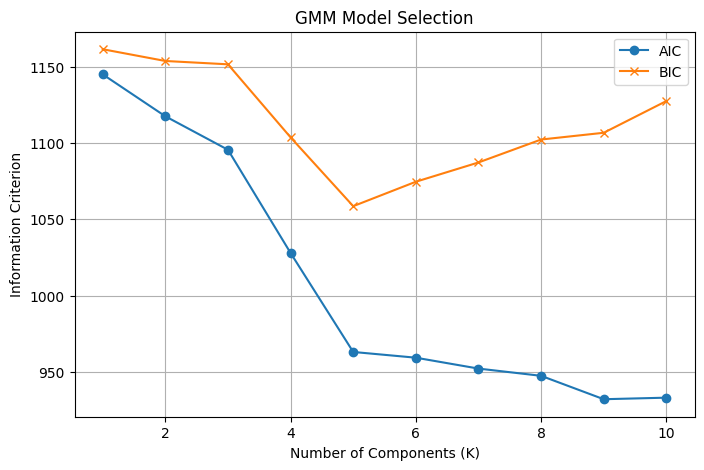

In [16]:
n_components = range(1, 11)
aic_values = []
bic_values = []

for k in n_components:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    aic_values.append(gmm.aic(X_scaled))
    bic_values.append(gmm.bic(X_scaled))

plt.figure(figsize=(8,5))
plt.plot(n_components, aic_values, marker='o', label='AIC')
plt.plot(n_components, bic_values, marker='x', label='BIC')
plt.xlabel('Number of Components (K)')
plt.ylabel('Information Criterion')
plt.title('GMM Model Selection')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
optimal_k = 5
gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

probs = gmm.predict_proba(X_scaled)
print("Cluster probabilities sample:\n", probs[:5])

labels = gmm.predict(X_scaled)
data['GMM_Cluster'] = labels

Cluster probabilities sample:
 [[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


In [18]:
log_likelihood = gmm.score(X_scaled) * X_scaled.shape[0] 
sil_score = silhouette_score(X_scaled, labels)

print(f"Log-Likelihood: {log_likelihood:.2f}")
print(f"Silhouette Score: {sil_score:.2f}")
print(f"AIC: {gmm.aic(X_scaled):.2f}, BIC: {gmm.bic(X_scaled):.2f}")

Log-Likelihood: -452.50
Silhouette Score: 0.55
AIC: 963.00, BIC: 1058.65


Cluster Centers (scaled):
 [[-0.18510822 -0.030786  ]
 [ 0.98021511  1.23531662]
 [-1.35282052  1.16185843]
 [ 1.07840119 -1.3228595 ]
 [-1.27977698 -1.0882964 ]]


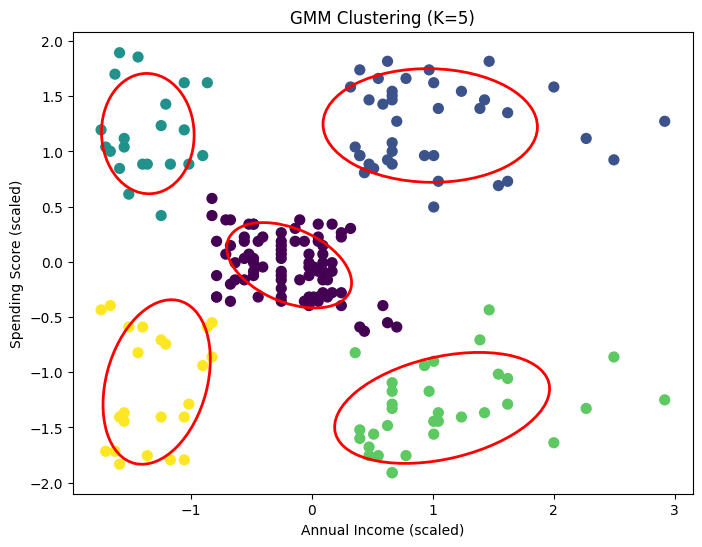

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np

plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis', s=50)

def plot_gmm_ellipses(gmm, ax):
    for i in range(gmm.n_components):
        mean = gmm.means_[i]
        cov = gmm.covariances_[i][:2,:2]  
        v, w = np.linalg.eigh(cov)
        v = 2. * np.sqrt(2.) * np.sqrt(v)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180. * angle / np.pi
        ell = Ellipse(xy=mean, width=v[0], height=v[1], angle=angle, edgecolor='red', facecolor='none', lw=2)
        ax.add_patch(ell)
print("Cluster Centers (scaled):\n", gmm.means_)
ax = plt.gca()
plot_gmm_ellipses(gmm, ax)
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title(f'GMM Clustering (K={optimal_k})')
plt.show()

In [20]:
from sklearn.cluster import KMeans

optimal_k = 5 
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

data['Cluster'] = kmeans_labels

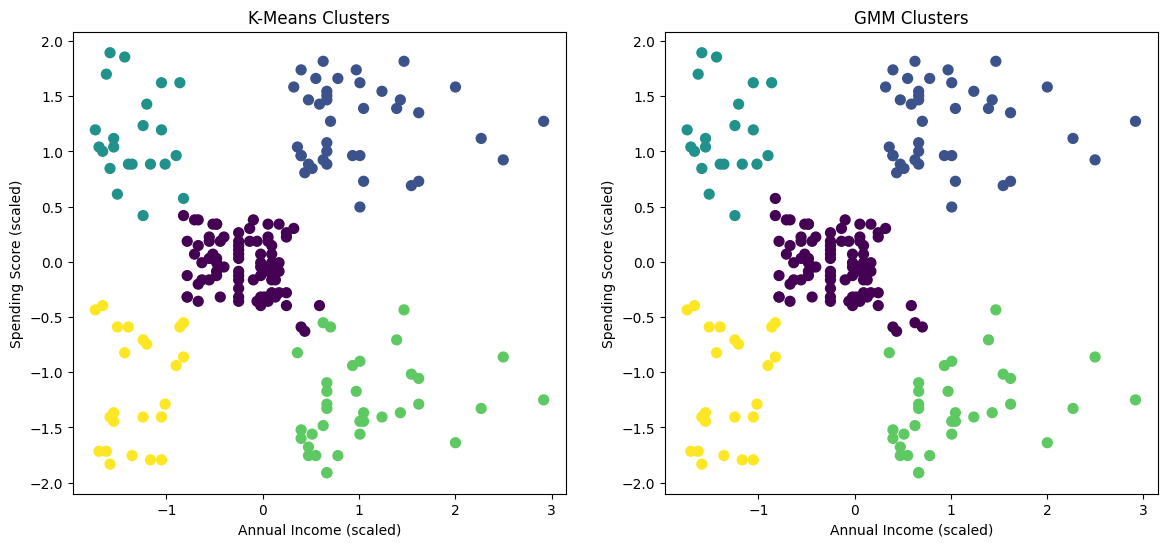

In [21]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=data['Cluster'], cmap='viridis', s=50)
plt.title('K-Means Clusters')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')

plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=data['GMM_Cluster'], cmap='viridis', s=50)
plt.title('GMM Clusters')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')

plt.show()

In [22]:
print("Sample cluster probabilities for first 5 points:\n", probs[:5])

overlap_count = np.sum(np.sum(probs > 0.3, axis=1) > 1)
print(f"Number of points with overlapping cluster membership: {overlap_count}/{X_scaled.shape[0]}")

Sample cluster probabilities for first 5 points:
 [[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]
Number of points with overlapping cluster membership: 3/200


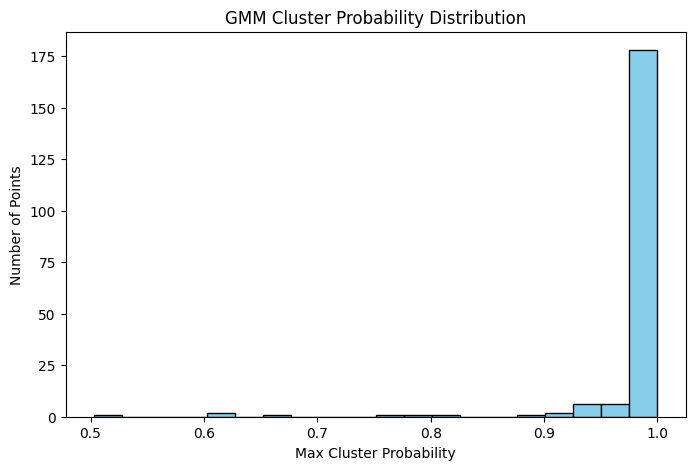

In [23]:
plt.figure(figsize=(8,5))
plt.hist(probs.max(axis=1), bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Max Cluster Probability")
plt.ylabel("Number of Points")
plt.title("GMM Cluster Probability Distribution")
plt.show()